# Commodities: which crops drive deforestation?

**Goal:** pick the 3 commodities that matter most for our study, using the DeDuCE data on deforestation attributed to agricultural and forestry commodities (Singh & Persson, 2001 to 2023).

A commodity is useful for our study only if:
1. **It causes a lot of deforestation** (hectares attributed by DeDuCE).
2. **It has a world price** in the World Bank Pink Sheet, so we can build the price index.
3. **It is traded on world markets**, so world price changes actually reach the farmers who clear the forest.

Output: `data/processed/deduce_selected_commodities.csv` (country-year deforestation for the 3 selected commodities).

## 0. Setup

In [1]:
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'

SOURCE_DEDUCE = "Source: DeDuCE, Singh & Persson (2026)"


def add_source(fig, text):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")

## 1. Load the DeDuCE data

Source: Singh & Persson, *Global patterns of commodity-driven deforestation and associated carbon emissions*, Nature Food (2026), doi:10.1038/s43016-026-01305-4. Model: https://github.com/chandrakant6492/DeDuCE

The file name has spaces and brackets, so we encode it before adding it to the URL.

In [2]:
BRANCH = "main"
BASE_URL = f"https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/{BRANCH}/data/"
DEDUCE_FILE = "1. DeDuCE_Deforestation_attributed to agricultural and forestry commodities (2001-2023).xlsx"

xls = pd.ExcelFile(BASE_URL + "raw/crops/" + urllib.parse.quote(DEDUCE_FILE))
print(xls.sheet_names)

['Deforestation attribution']


In [3]:
df = pd.read_excel(xls, sheet_name="Deforestation attribution")
df = df.rename(columns={
    "Continent/Country group": "region",
    "ISO": "iso3",
    "Producer country": "country",
    "Year": "year",
    "Commodity group": "commodity_group",
    "Commodity": "commodity",
    "Deforestation attribution, unamortized (ha)": "defor_ha",
    "Deforestation emissions incl. peat drainage, amortized (MtCO2)": "defor_co2_mt",
})
print(df.shape)
print(df.year.min(), "-", df.year.max(), "|", df.iso3.nunique(), "countries |", df.commodity.nunique(), "commodities")
df.head()

(213562, 13)
2001 - 2023 | 185 countries | 182 commodities


,region,iso3,country,year,commodity_group,commodity,defor_ha,"Deforestation risk, amortized (ha)","Deforestation emissions excl. peat drainage, unamortized (MtCO2)","Deforestation emissions excl. peat drainage, amortized (MtCO2)",Peatland drainage emissions (MtCO2),defor_co2_mt,Integrated Quality Index
0,Rest of Asia,AFG,Afghanistan,2001,Fruit and nuts,"Almonds, in shell",0.327012,NaN,0.000080,NaN,4.971445e-08,4.971445e-08,0.386864
1,Rest of Asia,AFG,Afghanistan,2002,Fruit and nuts,"Almonds, in shell",0.315983,NaN,0.000083,NaN,1.712462e-07,1.712462e-07,0.362607
2,Rest of Asia,AFG,Afghanistan,2003,Fruit and nuts,"Almonds, in shell",0.309583,NaN,0.000081,NaN,4.480086e-07,4.480086e-07,0.472182
3,Rest of Asia,AFG,Afghanistan,2004,Fruit and nuts,"Almonds, in shell",0.000000,NaN,0.000000,NaN,4.480086e-07,4.480086e-07,NaN
4,Rest of Asia,AFG,Afghanistan,2005,Fruit and nuts,"Almonds, in shell",0.022733,0.195062,0.000005,0.00005,4.811899e-07,5.039824e-05,0.413855


## 2. Which commodities cause the most deforestation?

We sum the deforestation attributed to each commodity over all countries and years (unamortized hectares).

In [4]:
total_ha = df.defor_ha.sum()
n_years = df.year.nunique()

ranking = (df.groupby(["commodity_group", "commodity"])
             .agg(defor_ha=("defor_ha", "sum"))
             .reset_index()
             .sort_values("defor_ha", ascending=False)
             .reset_index(drop=True))
ranking["share"] = ranking.defor_ha / total_ha
ranking["cum_share"] = ranking.share.cumsum()

# how concentrated is each commodity? number of countries with more than 1000 ha per year, and the biggest country
by_country = df.groupby(["commodity", "iso3"]).defor_ha.sum()
ranking["n_countries_1kha_yr"] = [(by_country[c] / n_years > 1000).sum() for c in ranking.commodity]
ranking["top_country"] = [by_country[c].idxmax() for c in ranking.commodity]
ranking["top_country_share"] = [by_country[c].max() / by_country[c].sum() for c in ranking.commodity]

print(f"Total attributed deforestation: {total_ha / 1e6:.1f} M ha")
ranking.head(15).style.format({"defor_ha": "{:,.0f}", "share": "{:.1%}", "cum_share": "{:.1%}", "top_country_share": "{:.0%}"})

Total attributed deforestation: 128.2 M ha


,commodity_group,commodity,defor_ha,share,cum_share,n_countries_1kha_yr,top_country,top_country_share
0,Pasture,Cattle meat,"49,535,947",38.6%,38.6%,46,BRA,64%
1,Forest plantation,Forest plantation (Unclassified),"15,881,941",12.4%,51.0%,27,CHN,39%
2,Oilseeds and oleaginous fruits,Oil palm fruit,"10,780,086",8.4%,59.4%,18,IDN,73%
3,Oilseeds and oleaginous fruits,Soya beans,"6,532,126",5.1%,64.5%,15,BRA,54%
4,Cereals,Maize (corn),"6,261,196",4.9%,69.4%,35,COD,23%
5,Cereals,Rice,"5,487,640",4.3%,73.7%,28,COD,30%
6,Edible roots and tubers with high starch or inulin content,"Cassava, fresh","4,865,472",3.8%,77.5%,20,COD,64%
7,"Stimulant, spice and aromatic crops",Cocoa beans,"2,816,079",2.2%,79.7%,12,CIV,57%
8,Pasture,Leather,"2,607,155",2.0%,81.7%,12,BRA,64%
9,Fibre crops,Natural rubber in primary forms,"1,701,028",1.3%,83.1%,13,CIV,19%


## 3. Filter: is there a world price?

We check which candidates have a price series in the World Bank Pink Sheet (`commodity_prices_annual.csv`).

In [5]:
prices = pd.read_csv(BASE_URL + "processed/commodity_prices_annual.csv")

# DeDuCE commodity name -> Pink Sheet price series (None = no world price)
price_series = {
    "Cattle meat": "Beef",
    "Forest plantation (Unclassified)": None,  # mix of tree species, no single price
    "Oil palm fruit": "Palm oil",
    "Soya beans": "Soybeans",
    "Maize (corn)": "Maize",
    "Rice": "Rice, Thai 5%",
    "Cassava, fresh": None,
    "Cocoa beans": "Cocoa",
    "Leather": None,  # by-product of cattle
    "Natural rubber in primary forms": "Rubber, RSS3",
    "Beans, dry": None,
    "Sugar cane": "Sugar, world",
    "Coffee, green": "Coffee, Arabica",
}
available = set(prices.commodity.unique())
candidates = ranking.head(13).copy()
candidates["price_series"] = candidates.commodity.map(price_series)
candidates["has_price"] = candidates.price_series.isin(available)
candidates[["commodity", "share", "price_series", "has_price"]].style.format({"share": "{:.1%}"})

,commodity,share,price_series,has_price
0,Cattle meat,38.6%,Beef,True
1,Forest plantation (Unclassified),12.4%,nan,False
2,Oil palm fruit,8.4%,Palm oil,True
3,Soya beans,5.1%,Soybeans,True
4,Maize (corn),4.9%,Maize,True
5,Rice,4.3%,"Rice, Thai 5%",True
6,"Cassava, fresh",3.8%,nan,False
7,Cocoa beans,2.2%,Cocoa,True
8,Leather,2.0%,nan,False
9,Natural rubber in primary forms,1.3%,"Rubber, RSS3",True


## 4. Filter: is the commodity traded on world markets?

The DeDuCE 2001-2023 file only has the attribution sheet, so we take the trade information from the earlier releases, which trace the deforestation embodied in each commodity to the country that consumes it. Share of deforestation that ends up **exported** (consumer country different from producer country):

| Commodity | Pendrill et al. 2022 (2005-2018) | DeDuCE 2024 (2005-2022) |
|---|---|---|
| Cattle meat | 12% | 14% |
| Oil palm | 60% | 63% |
| Soybeans | 72% | 70% |
| Maize | 13% | 11% |
| Rice | 4% | 4% |
| Cassava | 3% | 2% |
| Cocoa | 77% | 84% |
| Natural rubber | 70% | 71% |
| Sugar cane | 45% (raw sugar) | 20% |
| Coffee | 75% | 73% |

Sources: Pendrill et al. (2022), *Deforestation risk embodied in production and consumption* v1.1, sheet "Trade flows - Kastner"; Singh & Persson (2024), Zenodo record 10633818, sheet "Trade flows-physical".

Maize, rice and cassava cause a lot of deforestation, but mostly by smallholders growing food for local markets (the biggest country is DR Congo for all three). World prices hardly reach them, so they are a weak test of our question.

## 5. Selection

We keep **3 commodities**:

| Rank | Commodity | Why |
|---|---|---|
| 1 | **Cattle meat** | By far the biggest driver. Mostly consumed domestically, but Brazilian cattle prices follow world beef prices |
| 2 | **Oil palm** | Big, export-oriented, concentrated in Indonesia and Malaysia |
| 3 | **Soybeans** | Big, export-oriented, Brazil and the rest of South America |

These are the three biggest agricultural drivers with a world price, and the three for which we build the exposure and the price shock.

Left out: forest plantations (no single price), leather (by-product of cattle, would count the same clearing twice), maize, rice and cassava (mostly domestic food crops), sugar cane (smaller, less exported). **Cocoa** and **natural rubber** are export-oriented and have a Pink Sheet price, but they cause much less deforestation than the three we keep (2.2% and 1.3% of attributed deforestation, against 5.1% for soybeans); together with **coffee** they are the candidates if we want to extend the analysis.

In [6]:
SELECTED = ["Cattle meat", "Oil palm fruit", "Soya beans", ]

sel = ranking[ranking.commodity.isin(SELECTED)]
print(f"The 3 selected commodities cover {sel.share.sum():.1%} of all attributed deforestation")
print(f"and {sel.defor_ha.sum() / ranking[ranking.commodity_group != 'Forest plantation'].defor_ha.sum():.1%} of agricultural deforestation (without forest plantations)")

The 3 selected commodities cover 52.2% of all attributed deforestation
and 59.5% of agricultural deforestation (without forest plantations)


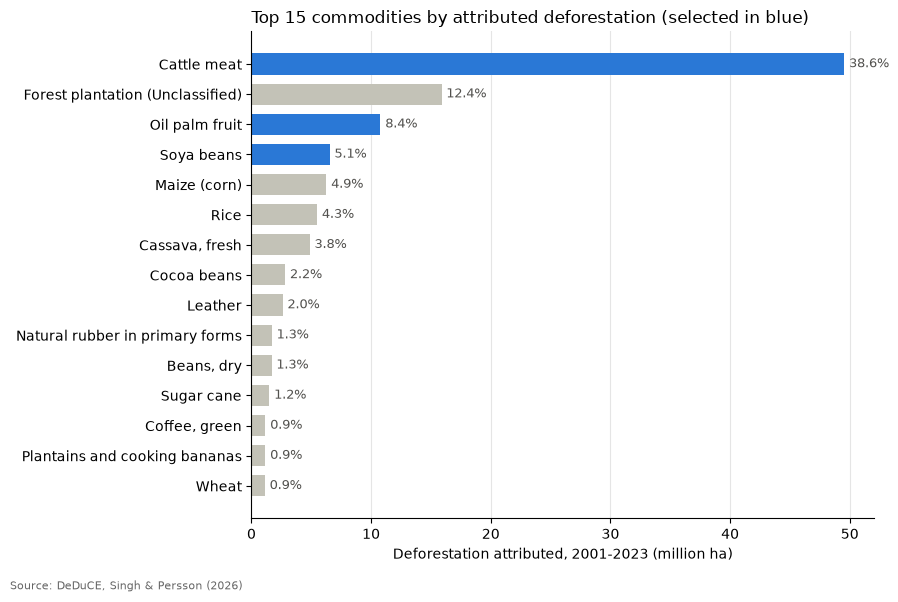

In [7]:
top = ranking.head(15).iloc[::-1]
colors = ["#2a78d6" if c in SELECTED else "#c3c2b7" for c in top.commodity]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.commodity, top.defor_ha / 1e6, color=colors, height=0.7)
for y, (v, s) in enumerate(zip(top.defor_ha / 1e6, top.share)):
    ax.text(v + 0.4, y, f"{s:.1%}", va="center", fontsize=9, color="#52514e")
ax.set_xlabel("Deforestation attributed, 2001-2023 (million ha)")
ax.set_title("Top 15 commodities by attributed deforestation (selected in blue)", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e5")
ax.set_axisbelow(True)
add_source(fig, SOURCE_DEDUCE)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

### Deforestation over time for the 3 selected commodities

Each panel has its own y-axis, because cattle is much bigger than the others.

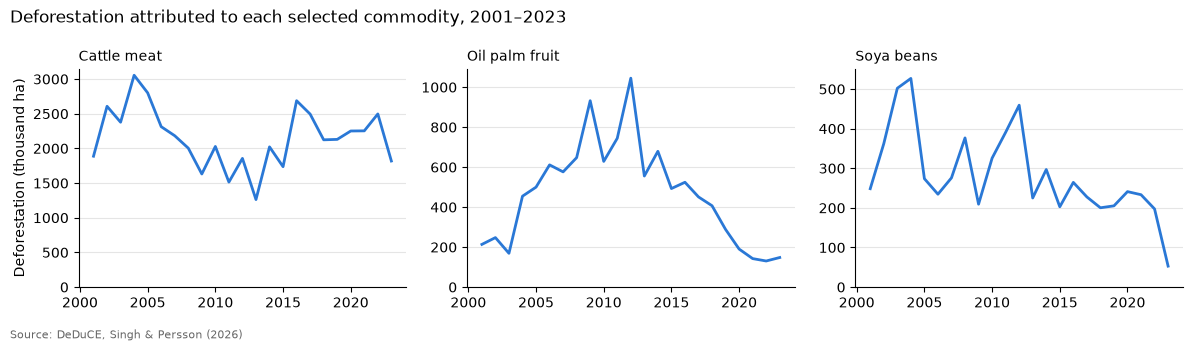

In [8]:
yearly = df[df.commodity.isin(SELECTED)].groupby(["commodity", "year"]).defor_ha.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, c in zip(axes, SELECTED):
    s = yearly[c] / 1e3
    ax.plot(s.index, s.values, color="#2a78d6", linewidth=2)
    ax.set_title(c, loc="left", fontsize=10)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5")
axes[0].set_ylabel("Deforestation (thousand ha)")
fig.suptitle("Deforestation attributed to each selected commodity, 2001–2023", x=0.01, ha="left")
add_source(fig, SOURCE_DEDUCE)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## 6. Save the selected commodities

Country-year deforestation for the 3 commodities, for the merge with prices and the forest loss panel.

In [9]:
out = (df[df.commodity.isin(SELECTED)]
         [["iso3", "country", "region", "year", "commodity", "defor_ha", "defor_co2_mt"]]
         .sort_values(["iso3", "commodity", "year"])
         .reset_index(drop=True))
print(out.shape)
out.to_csv("../data/processed/deduce_selected_commodities.csv", index=False)
out.head()

(7598, 7)


,iso3,country,region,year,commodity,defor_ha,defor_co2_mt
0,AFG,Afghanistan,Rest of Asia,2001,Cattle meat,2.797840,6.931292e-07
1,AFG,Afghanistan,Rest of Asia,2002,Cattle meat,6.513448,2.601605e-06
2,AFG,Afghanistan,Rest of Asia,2003,Cattle meat,2.839102,6.306455e-06
3,AFG,Afghanistan,Rest of Asia,2004,Cattle meat,3.040711,6.306455e-06
4,AFG,Afghanistan,Rest of Asia,2005,Cattle meat,6.925111,1.058969e-03
